<a href="https://colab.research.google.com/github/Maxxx-VS/IMA_SibADI/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_2_2_CO2(Me).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Зависимость концентрации CO2 (CO2) от крутящего момента (Me)

In [1]:
!pip install --upgrade patsy statsmodels

In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [8]:
# Загрузка данных и конвертация в CSV
file_name = '/content/multiregress042020.xlsx'
df = pd.read_excel(file_name, header=1)
csv_file_name = 'multiregress042020.csv'
df.to_csv(csv_file_name, index=False, encoding='utf-8-sig')


# Создаю переменные
X_data = df['Me']
Y_data = df['CO2']

# Проверка перых 3 строк
print(df.head(3))

   i    ne   Me    tc      ge    CO2     NOx
0  1  1200  140  80.7  233.16   5.88  665.25
1  2  1200  210  82.8  225.23   8.67  900.50
2  3  1200  252  83.2  232.83  10.58  957.19


In [9]:
# SciPy
slope, intercept, r_value, p_value, std_err = stats.linregress(X_data, Y_data)

print(f"Уравнение регрессии: CO2 = {intercept:.4f} + {slope:.4f} * Me")
print(f"Коэффициент корреляции (R): {r_value:.4f}")
print(f"Коэффициент детерминации (R^2): {r_value**2:.4f}")
print(f"P-значение: {p_value:.4e} (Если < 0.05, связь статистически значима)")

Me_forecast = 180 # например Me = 180 Нм
co2_forecast = intercept + slope * Me_forecast
print(f"\nТочечный прогноз: при крутящем моменте {Me_forecast} Нм концентрация CO2 составит {co2_forecast:.2f}%\n")



Уравнение регрессии: CO2 = 2.0422 + 0.0349 * Me
Коэффициент корреляции (R): 0.9850
Коэффициент детерминации (R^2): 0.9702
P-значение: 9.9078e-17 (Если < 0.05, связь статистически значима)

Точечный прогноз: при крутящем моменте 180 Нм концентрация CO2 составит 8.33%



                            OLS Regression Results                            
Dep. Variable:                    CO2   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.969
Method:                 Least Squares   F-statistic:                     650.9
Date:                Sun, 03 May 2026   Prob (F-statistic):           9.91e-17
Time:                        08:54:41   Log-Likelihood:                -15.787
No. Observations:                  22   AIC:                             35.57
Df Residuals:                      20   BIC:                             37.76
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0422      0.225      9.065      0.0

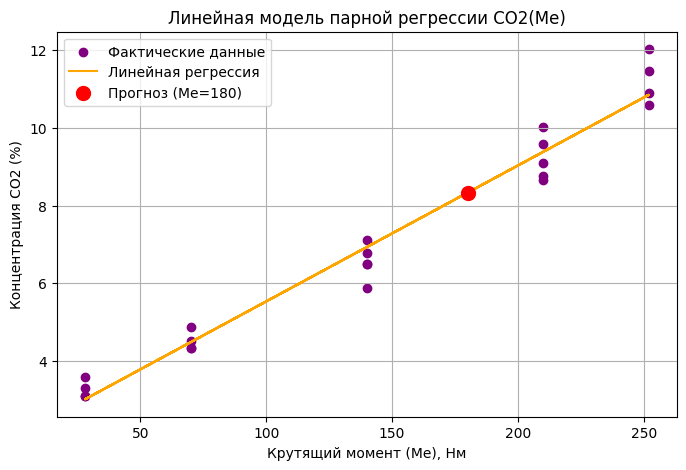

In [12]:
# Statsmodels
X_sm = sm.add_constant(X_data)
model_sm = sm.OLS(Y_data, X_sm).fit()

# Вывод полной таблицы
print(model_sm.summary())

forecast_sm = model_sm.predict([1, Me_forecast])
print(f"\nТочечный прогноз (Statsmodels) при Me={Me_forecast}: {forecast_sm[0]:.2f}")

# Визуализация
plt.figure(figsize=(8, 5))
plt.scatter(X_data, Y_data, color='purple', label='Фактические данные')
plt.plot(X_data, intercept + slope * X_data, color='orange', label='Линейная регрессия')
plt.scatter([Me_forecast], [co2_forecast], color='red', s=100, zorder=5, label=f'Прогноз (Me={Me_forecast})')
plt.title('Линейная модель парной регрессии CO2(Me)')
plt.xlabel('Крутящий момент (Me), Нм')
plt.ylabel('Концентрация CO2 (%)')
plt.legend()
plt.grid(True)
plt.show()

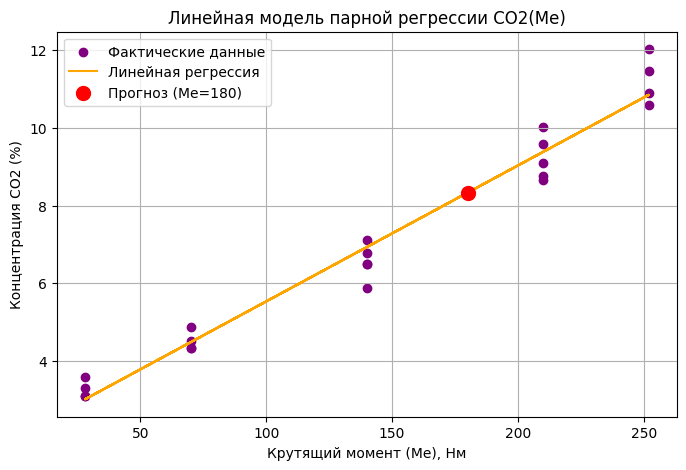